# Tutorial 1: Player strategies, masking strategies, and failure modes

Same image throughout. We vary model architecture, how the image is split into players (SLIC superpixels vs ViT patch groups), and how missing regions are filled in.

- **Architectures**: `ResNetArchitecture`, `ViTArchitecture`, `ConvNeXtArchitecture`, `DINOv2Architecture`, `CLIPArchitecture`
- **Players**: `SuperpixelStrategy`, `PatchStrategy`
- **Masking**: `MeanColorMasking`, `ZeroMasking`, `BlurMasking`, `DatasetMeanMasking`, `GaussianNoiseMasking`, `BoolMaskedPosStrategy`, `MaskTokenStrategy`

Section 6 puts all architectures on one row. Each panel explains a different target (see the subtitle). The last section stress-tests adversarial and out-of-distribution inputs.


In [1]:
from __future__ import annotations

from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torchvision import models, transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


### Load a single image used everywhere below


image shape: (224, 224, 3)


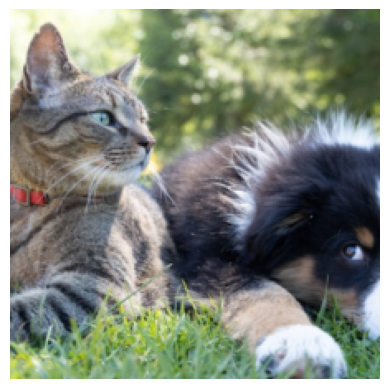

In [2]:
URL = (
    "https://images.unsplash.com/photo-1623387641168-d9803ddd3f35?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
resize = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
pil_image = resize(raw)
image = np.array(pil_image)
print("image shape:", image.shape)

plt.imshow(image)
plt.axis("off")
plt.show()

Cat and dog in the same crop. In section 1 ResNet picks **tabby**; on average, superpixels on the cat tend toward positive first-order values and patches on the dog toward negative ones—hiding the dog nudges the tabby score up (individual cat superpixels can still be slightly negative). Handy when you want a scene where two objects pull the prediction in opposite directions.


### A helper for visualizing first-order Shapley values as a heatmap over the image

In [3]:
import matplotlib.colors as mcolors
from matplotlib import cm


def heatmap_from_pixel_masks(values, masks, image_shape):
    """Project per-player Shapley values back onto pixel space using player masks."""
    heat = np.zeros(image_shape[:2])
    for i, v in enumerate(values):
        heat[masks[i]] = v
    return heat


def plot_overlay(image, heat, title, ax):
    ax.imshow(image)
    vmax = max(abs(heat.min()), abs(heat.max())) + 1e-9
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    ax.imshow(heat, cmap=cm.RdYlGn, norm=norm, alpha=0.55)
    ax.set_title(title)
    ax.axis("off")

## 1. ResNet-18 × SuperpixelStrategy × pixel maskers

Four pixel-space maskers on the same superpixel partition. Switching the masker keeps the players fixed but changes what "absent" means. `DatasetMeanMasking` uses ImageNet RGB means on the 0–255 scale; `GaussianNoiseMasking` uses a fixed random seed for reproducibility.

Heatmaps use a diverging colormap: **green = positive Shapley value** (presence raises the target score), **red = negative** (presence lowers it). See the colorbar on the figure below.


ResNet predicted class: 281 tabby


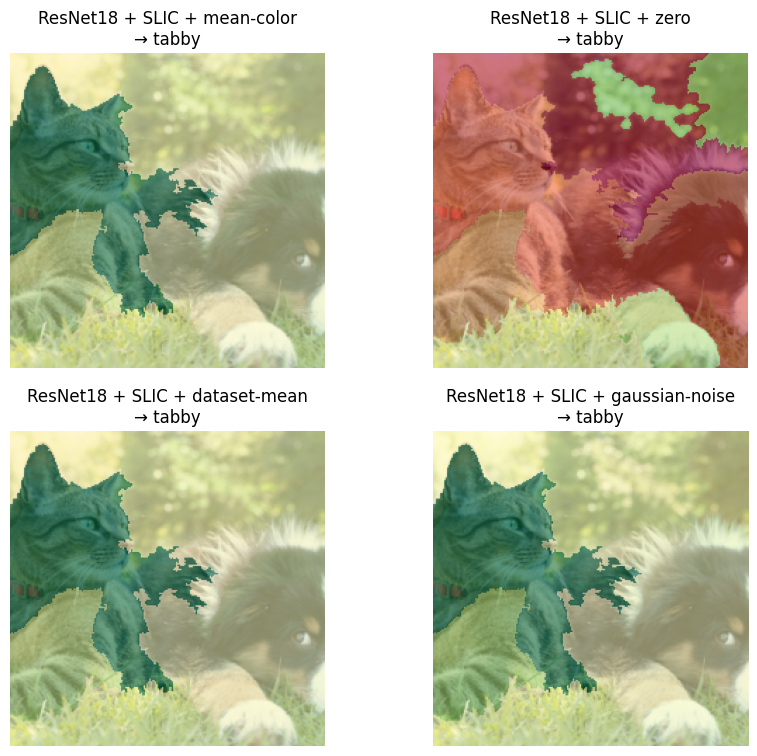

In [4]:
from shapiq import ImageExplainer
from shapiq.vision import ResNetArchitecture, SuperpixelStrategy
from shapiq.vision.masking import (
    DatasetMeanMasking,
    GaussianNoiseMasking,
    MeanColorMasking,
    ZeroMasking,
)

IMAGENET_MEAN_RGB = np.array([0.485, 0.456, 0.406]) * 255

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).eval().to(device)
weights = models.ResNet18_Weights.DEFAULT
preprocess = weights.transforms()

with torch.no_grad():
    class_id = int(resnet(preprocess(pil_image).unsqueeze(0).to(device)).argmax(-1).item())
resnet_label = weights.meta["categories"][class_id]
print("ResNet predicted class:", class_id, resnet_label)


def resnet_model(batch_hwc: np.ndarray) -> np.ndarray:
    pil_batch = [Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8)) for arr in batch_hwc]
    tensors = torch.stack([preprocess(im) for im in pil_batch]).to(device)
    with torch.no_grad():
        logits = resnet(tensors)
    return torch.softmax(logits, dim=-1)[:, class_id].cpu().numpy()


results_resnet = {}
for masker_name, masker in [
    ("mean-color", MeanColorMasking()),
    ("zero", ZeroMasking()),
    ("dataset-mean", DatasetMeanMasking(mean_color=IMAGENET_MEAN_RGB)),
    ("gaussian-noise", GaussianNoiseMasking(mean=128.0, std=40.0, random_state=0)),
]:
    arch = ResNetArchitecture(model=resnet_model, masking_strategy=masker)
    explainer = ImageExplainer(
        architecture=arch,
        data=image,
        player_strategy=SuperpixelStrategy(n_segments=10),
        batch_size=16,
        random_state=0,
    )
    iv = explainer.explain_function(image, budget=128)
    results_resnet[masker_name] = (iv, explainer.imputer.player_masks)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (name, (iv, masks)) in zip(axes.ravel(), results_resnet.items(), strict=False):
    first_order = iv.get_n_order_values(1)
    heat = heatmap_from_pixel_masks(first_order, masks, image.shape)
    plot_overlay(image, heat, f"ResNet18 + SLIC + {name}\n→ {resnet_label}", ax)

## 2. ViT-B/16 × PatchStrategy × MaskTokenStrategy

Latent-space masking on a 3×3 patch grid via `MaskTokenStrategy` (the default on `ViTArchitecture`).

ViT explains whatever class it predicts on the full image (argmax). On this crop that label is often not the same one ResNet returns.

Even for the predicted class, red and green can appear on the same object: a coarse 3×3 grid mixes body parts, and removal-based Shapley values capture interactions between players—not just "is this patch visually part of the class?"


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT predicted class: Bernese mountain dog


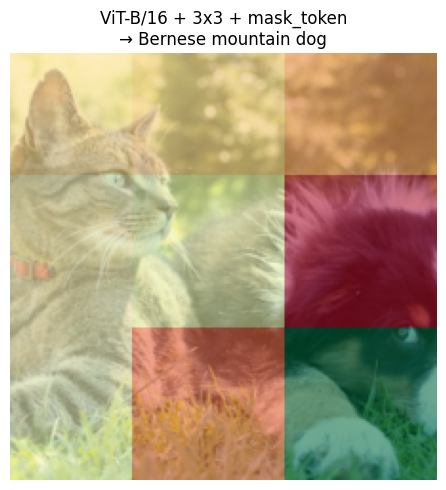

In [5]:
from transformers import ViTForImageClassification, ViTImageProcessor

from shapiq.vision import PatchStrategy, ViTArchitecture
from shapiq.vision.masking import MaskTokenStrategy

vit_id = "google/vit-base-patch16-224"
vit_processor = ViTImageProcessor.from_pretrained(vit_id)
vit_model = ViTForImageClassification.from_pretrained(vit_id).eval()
grid_size = vit_model.config.image_size // vit_model.config.patch_size
patch_strategy = PatchStrategy(
    grid_size=grid_size, n_players=9
)  # 3×3 macro-regions on 14×14 tokens

arch_vit = ViTArchitecture(
    model=vit_model, processor=vit_processor, masking_strategy=MaskTokenStrategy()
)
explainer_vit = ImageExplainer(
    architecture=arch_vit,
    data=image,
    player_strategy=patch_strategy,
    batch_size=8,
    random_state=0,
)
iv_vit = explainer_vit.explain_function(image, budget=128)
vit_target_label = vit_model.config.id2label[arch_vit._class_id]
print("ViT predicted class:", vit_target_label)


def latent_heatmap(iv, patch_strategy: PatchStrategy, image_shape):
    """Project latent patch attributions onto pixels using PatchStrategy boundaries."""
    first = iv.get_n_order_values(1)
    H, W = image_shape[:2]
    side = patch_strategy.side
    grid_size = patch_strategy.grid_size
    patch_px = H // grid_size
    heat = np.zeros((H, W))
    for i, v in enumerate(first):
        row, col = i // side, i % side
        y0 = (row * grid_size // side) * patch_px
        y1 = ((row + 1) * grid_size // side) * patch_px
        x0 = (col * grid_size // side) * patch_px
        x1 = ((col + 1) * grid_size // side) * patch_px
        heat[y0:y1, x0:x1] = v
    return heat


fig, ax = plt.subplots(1, 1, figsize=(5, 5))
heat = latent_heatmap(iv_vit, patch_strategy, image.shape)
plot_overlay(image, heat, f"ViT-B/16 + 3x3 + mask_token\n→ {vit_target_label}", ax)
plt.tight_layout()
plt.show()

## 3. ConvNeXt-tiny × SuperpixelStrategy × MeanColorMasking

Same SLIC setup as ResNet (10 segments on this image). `ConvNeXtArchitecture` is pixel masking plus the Hugging Face processor.


The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

ConvNeXt predicted class: tiger cat


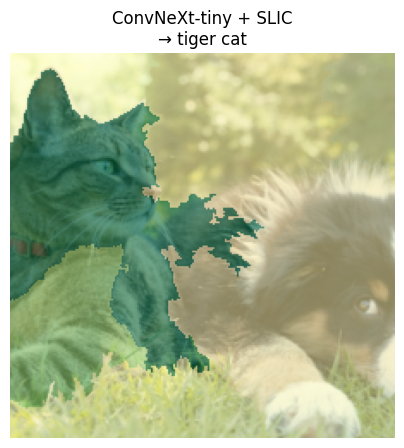

In [6]:
from transformers import AutoImageProcessor, ConvNextForImageClassification

from shapiq.vision import ConvNeXtArchitecture

convnext_id = "facebook/convnext-tiny-224"
convnext_processor = AutoImageProcessor.from_pretrained(convnext_id)
convnext_model = ConvNextForImageClassification.from_pretrained(convnext_id).eval()

convnext_arch = ConvNeXtArchitecture(model=convnext_model, processor=convnext_processor)
explainer = ImageExplainer(
    architecture=convnext_arch,
    data=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=16,
    random_state=0,
)
iv_convnext = explainer.explain_function(image, budget=128)
masks_convnext = explainer.imputer.player_masks
convnext_label = convnext_model.config.id2label[convnext_arch.class_id]
print("ConvNeXt predicted class:", convnext_label)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
first = iv_convnext.get_n_order_values(1)
heat = heatmap_from_pixel_masks(first, explainer.imputer.player_masks, image.shape)
plot_overlay(image, heat, f"ConvNeXt-tiny + SLIC\n→ {convnext_label}", ax)
plt.show()

## 4. DINOv2 × SuperpixelStrategy × MeanColorMasking

Again the same 10 SLIC superpixels. DINOv2 has no classifier head: the score is cosine similarity between the masked embedding and the embedding of the full image.


The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

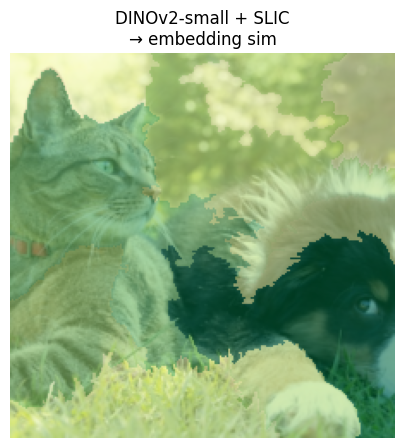

In [7]:
from transformers import AutoImageProcessor, AutoModel

from shapiq.vision import DINOv2Architecture

dino_id = "facebook/dinov2-small"
dino_processor = AutoImageProcessor.from_pretrained(dino_id)
dino_model = AutoModel.from_pretrained(dino_id).eval()

dino_arch = DINOv2Architecture(model=dino_model, processor=dino_processor)
explainer = ImageExplainer(
    architecture=dino_arch,
    data=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=16,
    random_state=0,
)
iv_dino = explainer.explain_function(image, budget=128)
masks_dino = explainer.imputer.player_masks

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
first = iv_dino.get_n_order_values(1)
heat = heatmap_from_pixel_masks(first, explainer.imputer.player_masks, image.shape)
plot_overlay(image, heat, "DINOv2-small + SLIC\n→ embedding sim", ax)
plt.show()

## 5. CLIP × SuperpixelStrategy × MeanColorMasking

Same SLIC regions again. CLIP scores the image against a short list of text prompts. We explain the softmax weight on one chosen prompt.


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


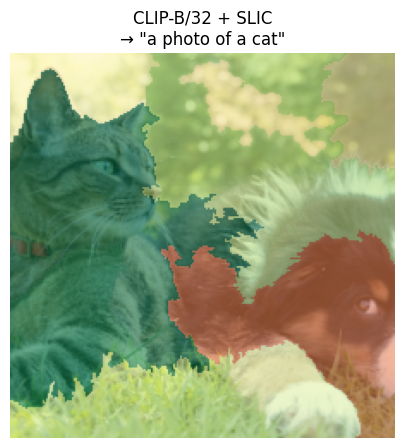

In [8]:
from transformers import CLIPModel, CLIPProcessor

from shapiq.vision import CLIPArchitecture

clip_id = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_id)
clip_model = CLIPModel.from_pretrained(clip_id).eval()

PROMPTS = ["a photo of a cat", "a photo of a dog", "a photo of a car", "a photo of a tree"]
clip_arch = CLIPArchitecture(
    model=clip_model, processor=clip_processor, text_prompts=PROMPTS, target_prompt_idx=0
)
explainer = ImageExplainer(
    architecture=clip_arch,
    data=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=8,
    random_state=0,
)
iv_clip = explainer.explain_function(image, budget=128)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
first = iv_clip.get_n_order_values(1)
heat = heatmap_from_pixel_masks(first, explainer.imputer.player_masks, image.shape)
plot_overlay(image, heat, f'CLIP-B/32 + SLIC\n→ "{PROMPTS[0]}"', ax)
plt.show()

## 6. Side-by-side: same image, all architectures

One figure, five models. ResNet, ConvNeXt, DINOv2, and CLIP share the same SLIC partition on this image, so the tile outlines in those panels line up. ViT is different: it uses a 3×3 patch grid in token space.

The colors are not directly comparable across panels. Each heatmap answers a different question, ResNet's top ImageNet class, ViT's own argmax, ConvNeXt's top class, DINO similarity to the original embedding, or one CLIP prompt. Read the subtitle on each panel for the target.


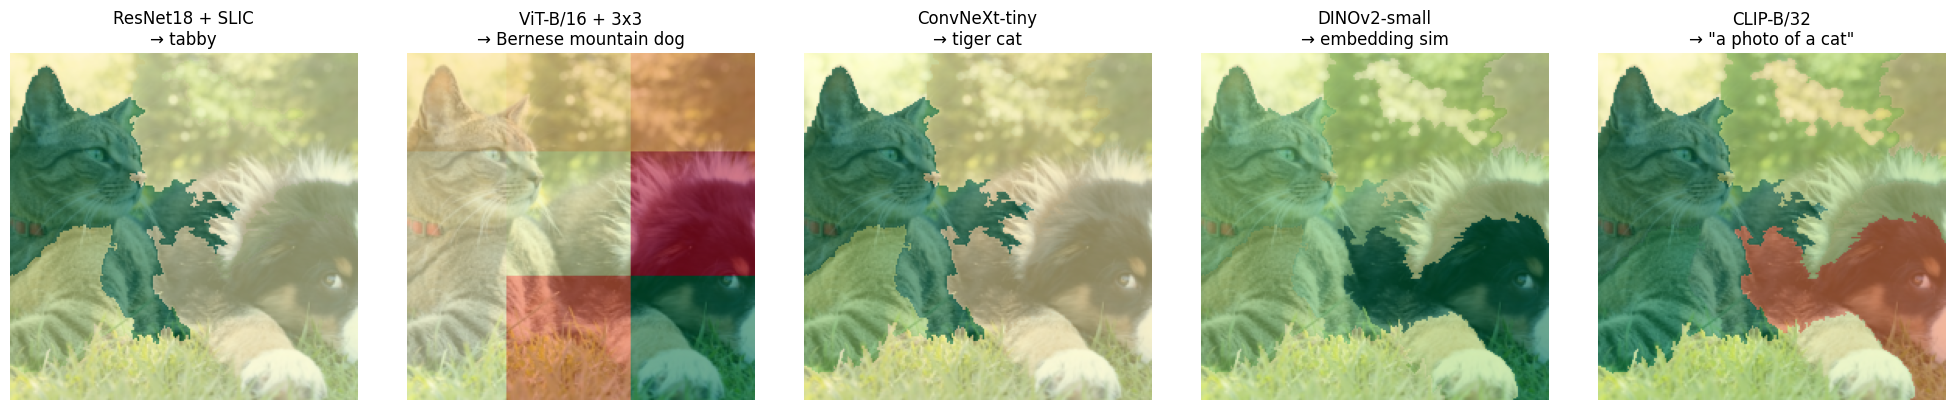

In [9]:
resnet_label = weights.meta["categories"][class_id]

panels = [
    (
        f"ResNet18 + SLIC\n→ {resnet_label}",
        results_resnet["mean-color"][0],
        results_resnet["mean-color"][1],
        "pixel",
    ),
    (f"ViT-B/16 + 3x3\n→ {vit_target_label}", iv_vit, None, "latent"),
    (f"ConvNeXt-tiny\n→ {convnext_label}", iv_convnext, masks_convnext, "pixel"),
    ("DINOv2-small\n→ embedding sim", iv_dino, masks_dino, "pixel"),
    (f'CLIP-B/32\n→ "{PROMPTS[0]}"', iv_clip, explainer.imputer.player_masks, "pixel"),
]

fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
for ax, (title, iv, masks, kind) in zip(axes, panels, strict=False):
    first = iv.get_n_order_values(1)
    heat = (
        latent_heatmap(iv, patch_strategy, image.shape)
        if kind == "latent"
        else heatmap_from_pixel_masks(first, masks, image.shape)
    )
    plot_overlay(image, heat, title, ax)
plt.tight_layout()
plt.show()

---

## 7. Failure modes and edge cases

Honest evaluation of a method requires showing where it breaks down. In this section we stress-test the imputer with two types of challenging inputs:

1. **Adversarial noise**: a small structured perturbation that flips the ResNet prediction with minimal perceptual change. The explanation should behave differently on the attacked image.
2. **Out-of-distribution (OOD) input**: pure Gaussian noise. No model was trained on this; the explanation will be unreliable.

These examples illustrate important caveats: Shapley values faithfully decompose *whatever the model outputs*, but if the model itself is confused or fooled, the explanation inherits that confusion.


### 7.1  Adversarial example (Fast Gradient Sign Method)

Original prediction: 281 — tabby
Adversarial prediction: 154 — Pekinese
Label change: YES — attack succeeded


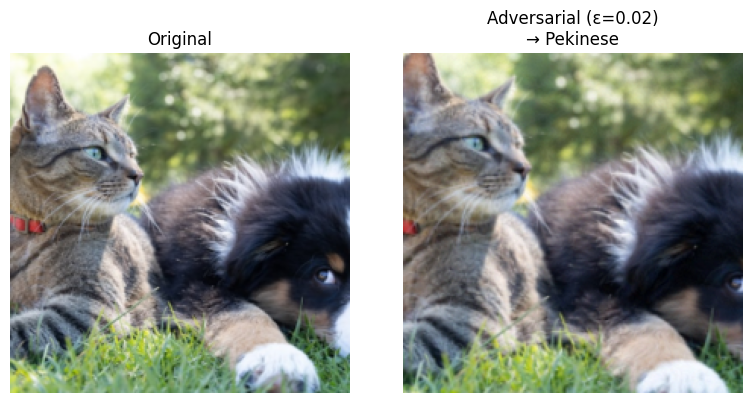

In [10]:
import torch.nn.functional as F

# Use the same preprocessing as section 1 (ResNet18_Weights.transforms on uint8 arrays).
rn18_weights = models.ResNet18_Weights.DEFAULT
rn18_preprocess = rn18_weights.transforms()
rn18 = models.resnet18(weights=rn18_weights).eval().to(device)


def numpy_to_resnet_tensor(img: np.ndarray) -> torch.Tensor:
    return rn18_preprocess(Image.fromarray(img.astype(np.uint8)))


x = numpy_to_resnet_tensor(image).unsqueeze(0).to(device)
x.requires_grad_(True)

with torch.no_grad():
    logits = rn18(x.detach())
    target_class_rn = int(logits.argmax(-1).item())
print(
    f"Original prediction: {target_class_rn} — {rn18_weights.meta['categories'][target_class_rn]}"
)

loss = F.cross_entropy(rn18(x), torch.tensor([target_class_rn], device=device))
loss.backward()

epsilon = 0.02
x_adv = (x + epsilon * x.grad.sign()).detach()

with torch.no_grad():
    adv_logits = rn18(x_adv)
    adv_class = int(adv_logits.argmax(-1).item())

# Invert only the final normalize step for display (tensor is already model-ready).
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)
adv_image_np = (
    (x_adv.squeeze(0).cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy() * 255
).astype(np.uint8)

print(f"Adversarial prediction: {adv_class} — {rn18_weights.meta['categories'][adv_class]}")
print(
    f"Label change: {'YES — attack succeeded' if adv_class != target_class_rn else 'NO — attack failed'}"
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(adv_image_np)
axes[1].set_title(f"Adversarial (ε={epsilon})\n→ {rn18_weights.meta['categories'][adv_class]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

/Users/alex/IdeaProjects/shapiq/src/shapiq/vision/architecture.py:147: UserWarning: SLIC produced 12 superpixels (requested 10). Using all 12 segments as players.
  self._player_masks = player_strategy.get_masks(image)


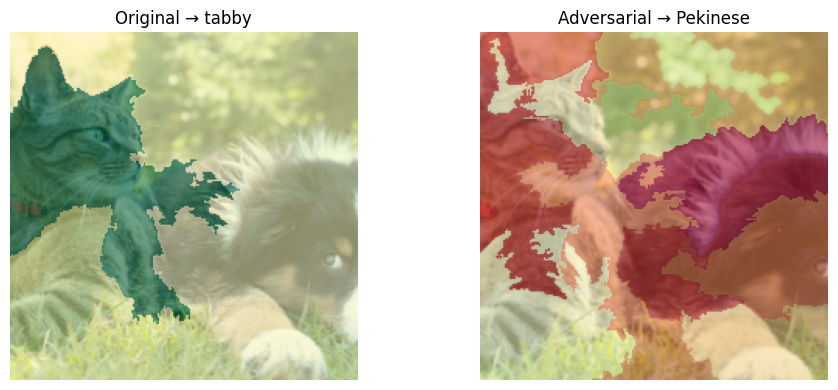


Interpretation:
 If the attack succeeded, the explanation on the adversarial image targets a *different* class.
 The attribution map may shift dramatically despite the images being perceptually similar.
 This illustrates that Shapley values explain the model, not the ground truth.
 Adversarial perturbations that fool the model also produce misleading explanations.


In [11]:
# Shapley values on the original image (same target class and preprocessing as section 1)


def resnet_callable(imgs: np.ndarray) -> np.ndarray:
    tensors = torch.stack([numpy_to_resnet_tensor(img) for img in imgs]).to(device)
    with torch.no_grad():
        logits = rn18(tensors)
    return F.softmax(logits, dim=-1)[:, target_class_rn].cpu().numpy()


arch_rn_orig = ResNetArchitecture(resnet_callable, masking_strategy=MeanColorMasking())
explainer_orig = ImageExplainer(
    architecture=arch_rn_orig,
    data=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=16,
    random_state=0,
)
sv_orig = explainer_orig.explain_function(budget=200)


def resnet_callable_adv(imgs: np.ndarray) -> np.ndarray:
    tensors = torch.stack([numpy_to_resnet_tensor(img) for img in imgs]).to(device)
    with torch.no_grad():
        logits = rn18(tensors)
        tgt = adv_class if adv_class != target_class_rn else target_class_rn
        return F.softmax(logits, dim=-1)[:, tgt].cpu().numpy()


arch_rn_adv = ResNetArchitecture(resnet_callable_adv, masking_strategy=MeanColorMasking())
explainer_adv = ImageExplainer(
    architecture=arch_rn_adv,
    data=adv_image_np,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=16,
    random_state=0,
)
sv_adv = explainer_adv.explain_function(budget=200)

masks_orig = explainer_orig.imputer.player_masks


def heatmap_sv(iv, masks, img):
    vals = iv.get_n_order_values(1)
    h = np.zeros(img.shape[:2], dtype=float)
    for i, m in enumerate(masks):
        h[m.astype(bool)] = vals[i]
    return h


masks_adv = explainer_adv.imputer.player_masks
heat_o = heatmap_sv(sv_orig, masks_orig, image)
heat_a = heatmap_sv(sv_adv, masks_adv, adv_image_np)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_overlay(
    image, heat_o, f"Original → {rn18_weights.meta['categories'][target_class_rn]}", axes[0]
)
plot_overlay(
    adv_image_np,
    heat_a,
    f"Adversarial → {rn18_weights.meta['categories'][adv_class]}",
    axes[1],
)
plt.tight_layout()
plt.show()

print(
    "\nInterpretation:\n"
    " If the attack succeeded, the explanation on the adversarial image targets a *different* class.\n"
    " The attribution map may shift dramatically despite the images being perceptually similar.\n"
    " This illustrates that Shapley values explain the model, not the ground truth.\n"
    " Adversarial perturbations that fool the model also produce misleading explanations."
)

### 7.2  Out-of-distribution input: pure Gaussian noise

ResNet on pure noise: class 107 'jellyfish', confidence = 6.12%


/Users/alex/IdeaProjects/shapiq/src/shapiq/vision/architecture.py:147: UserWarning: SLIC could only produce 1 superpixels for the requested 10. Using 1 players instead.
  self._player_masks = player_strategy.get_masks(image)
/Users/alex/IdeaProjects/shapiq/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


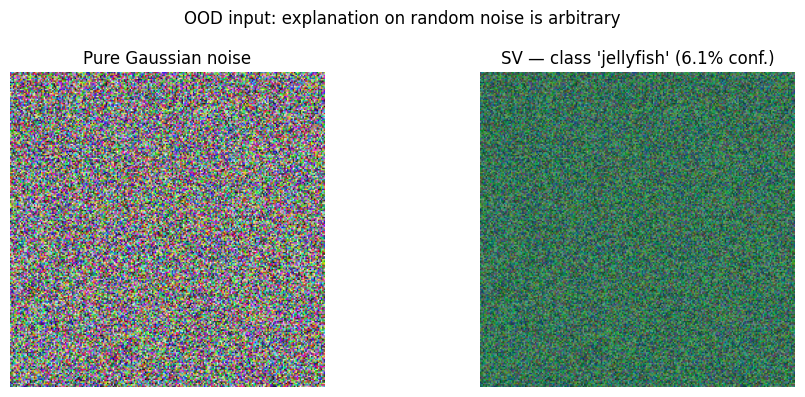


Interpretation:
 The model assigns a (possibly high) confidence to one class on random noise.
 The Shapley values faithfully decompose this nonsensical prediction.
 Red/green patches are artefacts of the random input, not semantically meaningful.
 Users should check model confidence and input quality before trusting explanations.


In [12]:
rng = np.random.default_rng(42)
noise_image = rng.integers(0, 256, image.shape, dtype=np.uint8)

x_noise = numpy_to_resnet_tensor(noise_image).unsqueeze(0).to(device)
with torch.no_grad():
    logits_noise = rn18(x_noise)
    noise_class = int(logits_noise.argmax(-1).item())
    noise_conf = float(logits_noise.softmax(dim=-1)[0, noise_class].item())

print(
    f"ResNet on pure noise: class {noise_class} '{rn18_weights.meta['categories'][noise_class]}', "
    f"confidence = {noise_conf:.2%}"
)


def resnet_noise_callable(imgs: np.ndarray) -> np.ndarray:
    tensors = torch.stack([numpy_to_resnet_tensor(img) for img in imgs]).to(device)
    with torch.no_grad():
        logits = rn18(tensors)
        return F.softmax(logits, dim=-1)[:, noise_class].cpu().numpy()


arch_rn_noise = ResNetArchitecture(resnet_noise_callable, masking_strategy=MeanColorMasking())
exp_noise = ImageExplainer(
    architecture=arch_rn_noise,
    data=noise_image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    batch_size=16,
    random_state=0,
)
sv_noise = exp_noise.explain_function(budget=200)
masks_noise = exp_noise.imputer.player_masks
heat_n = heatmap_sv(sv_noise, masks_noise, noise_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(noise_image)
axes[0].set_title("Pure Gaussian noise")
axes[0].axis("off")
v = max(abs(heat_n.min()), abs(heat_n.max())) + 1e-9
axes[1].imshow(noise_image)
axes[1].imshow(
    heat_n, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55
)
axes[1].set_title(
    f"SV — class '{rn18_weights.meta['categories'][noise_class]}' ({noise_conf:.1%} conf.)"
)
axes[1].axis("off")
plt.suptitle("OOD input: explanation on random noise is arbitrary", fontsize=12)
plt.tight_layout()
plt.show()

print(
    "\nInterpretation:\n"
    " The model assigns a (possibly high) confidence to one class on random noise.\n"
    " The Shapley values faithfully decompose this nonsensical prediction.\n"
    " Red/green patches are artefacts of the random input, not semantically meaningful.\n"
    " Users should check model confidence and input quality before trusting explanations."
)

### 7.3  Discussion: when to distrust the explanation

**Key takeaways from the failure-mode analysis:**

1. **Adversarial attacks invalidate the explanation semantics.** After a successful FGSM attack the model predicts a wrong class, and the Shapley values faithfully explain that wrong prediction. The resulting heatmap may look plausible but targets a class that does not match the visual content.

2. **OOD inputs produce arbitrary explanations.** Shapley values decompose the model's output for *any* input, including inputs far outside the training distribution. On pure noise the explanation is meaningless. Before trusting an explanation, verify that the input is in-distribution (e.g., inspect model confidence and use an anomaly detector).

3. **High confidence ≠ correct prediction.** A ResNet can assign high softmax probability to a wrong class, both on adversarial inputs and on noise. Confidence is not a reliable indicator of trustworthiness; the explanation should be interpreted alongside the confidence, not instead of it.

4. **Mitigation strategies:**
   - Always report prediction confidence alongside Shapley values.
   - Run explanations on multiple perturbed versions of the image (insertion/deletion curves) to verify stability.
   - For safety-critical applications, compare explanations across several masking strategies and report disagreement as a warning signal.

These limitations are intrinsic to removal-based explanations, not specific to `shapiq`. They reflect the fundamental coupling between the explanation and the model being explained.
